# OmniObject3D Selective Preprocessing

Downloads one category tar.gz at a time, samples 29 objects x 100 frames,
applies Kinect sensor noise to Blender depth, center-crops to 256x256,
and saves as PyTorch tensors matching the SUN RGB-D pipeline format.

**Est. pairs:** ~252K | **Runtime:** A100 recommended

## 1. Install & Imports

In [1]:
!pip install -q openxlab
!apt-get install -qq libopenexr-dev
!pip install -q OpenEXR Imath

import os, json, shutil, tarfile, random, subprocess
import numpy as np
import torch
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from scipy.ndimage import gaussian_filter
from collections import defaultdict, Counter

print('Imports OK')
!df -h /content

Imports OK
Filesystem      Size  Used Avail Use% Mounted on
overlay         226G   22G  205G  10% /


## 2. Configuration

In [2]:
BASE_OUT_DIR     = '/content/sparse_omni_256'
TMP_DIR          = '/content/omni_tmp'
DRIVE_OUTPUT_TAR = '/content/drive/MyDrive/datasets/OmniObject3D_Pretrain_256.tar.gz'

OBJECTS_PER_CAT  = 30
FRAMES_PER_OBJ   = 100
TARGET_SIZE      = 256
MIN_DEPTH_VALID  = 0.005
NOISE_SEED       = 42
MIN_FREE_GB      = 20    # stop if VM disk drops below this

REPO             = 'omniobject3d/OmniObject3D-New'
# Exact path openxlab uses when downloading
OPENXLAB_PREFIX  = 'omniobject3d___OmniObject3D-New'

os.makedirs(BASE_OUT_DIR, exist_ok=True)
os.makedirs(TMP_DIR,      exist_ok=True)

print(f'Output: {BASE_OUT_DIR}')
print(f'Tmp:    {TMP_DIR}')

Output: /content/sparse_omni_256
Tmp:    /content/omni_tmp


## 3. Category List

In [3]:
INDOOR_CATS = [
    # furniture (8)
    'chair', 'sofa', 'stool', 'table', 'cabinet', 'house', 'kennel', 'tvstand',
    # kitchen (10)
    'bowl', 'bottle', 'cup', 'teapot', 'kettle', 'knife',
    'dish', 'box', 'red_wine_glass', 'picnic_basket',
    # appliances (4)
    'microwaveoven', 'ricecooker', 'fan', 'timer',
    # tech / office (7)
    'keyboard', 'mouse', 'pad', 'remote_control',
    'projector', 'calculator', 'speaker',
    # clothing / accessories (9)
    'backpack', 'handbag', 'hat', 'helmet', 'shoe',
    'suitcase', 'umbrella', 'gloves', 'belt',
    # personal (10)
    'wallet', 'watch', 'tooth_brush', 'tooth_paste',
    'shampoo', 'soap', 'hair_dryer', 'hand_cream',
    'lipstick', 'laundry_detergent',
    # home (10)
    'book', 'clock', 'pillow', 'tissue', 'vase',
    'candle', 'dustbin', 'flower_pot', 'plant', 'light',
    # tools / sport (7)
    'hammer', 'scissor', 'tape_measure', 'dumbbell',
    'ball', 'kite', 'frisbee',
    # toys (6)
    'doll', 'teddy_bear', 'toy_car', 'rubik_cube', 'toy_boat', 'toy_plane',
    # food (13)
    'apple', 'banana', 'orange', 'egg', 'bread', 'cake',
    'broccoli', 'carrot', 'tomato', 'lemon', 'pineapple',
    'potato', 'mushroom',
    # misc (6)
    'eraser', 'chess', 'medicine_bottle', 'power_strip',
    'fire_extinguisher', 'garage_kit',
]

assert len(set(INDOOR_CATS)) == len(INDOOR_CATS) == 90
print(f'{len(INDOOR_CATS)} categories, {len(set(INDOOR_CATS))} unique')
print(f'90 x 30 x 100 = {90*30*100:,} pairs')

cat_to_idx = {cat: idx for idx, cat in enumerate(INDOOR_CATS)}

print(f'Categories:     {len(INDOOR_CATS)}')
print(f'Max objects:    {OBJECTS_PER_CAT} per category')
print(f'Frames/object:  {FRAMES_PER_OBJ}')
print(f'Est. pairs:     ~{len(INDOOR_CATS) * OBJECTS_PER_CAT * FRAMES_PER_OBJ:,}')

90 categories, 90 unique
90 x 30 x 100 = 270,000 pairs
Categories:     90
Max objects:    30 per category
Frames/object:  100
Est. pairs:     ~270,000


## 4. Mount Drive + Login

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.environ['OPENXLAB_AK'] = 'bmyqk5wpbaxl6x1vkzq9'
os.environ['OPENXLAB_SK'] = 'nl7kq9palyr6j3pwxolden7ezq4dwjmbgdm81yeo'

# Verify connection
ret = os.system('openxlab dataset info --dataset-repo omniobject3d/OmniObject3D-New > /dev/null 2>&1')
print(f'OpenDataLab connection: {"OK" if ret == 0 else "FAILED"}')

Mounted at /content/drive
OpenDataLab connection: OK


## 5. Kinect Noise Simulation

In [5]:
def simulate_kinect_depth(depth_clean, rgb=None, rng=None):
    if rng is None:
        rng = np.random.RandomState()

    depth = depth_clean.copy().astype(np.float32)
    H, W  = depth.shape

    # Zero out Blender background (rendered at ~65504 = float16 infinity sentinel)
    depth[depth > 100.0] = 0.0

    # Clip to Kinect sensor range (0.3m - 5.0m)
    depth[(depth < 0.3) | (depth > 5.0)] = 0.0
    valid = depth > 0
    depth = np.round(depth * 1000.0) / 1000.0
    sigma = np.zeros_like(depth)
    sigma[valid] = 0.0012 + 0.0019 * np.maximum(depth[valid] - 0.4, 0) ** 2
    noise = rng.normal(0, 1, (H, W)).astype(np.float32) * sigma
    depth[valid] += noise[valid]
    dy = np.abs(np.diff(depth, axis=0, prepend=depth[:1]))
    dx = np.abs(np.diff(depth, axis=1, prepend=depth[:, :1]))
    blend = np.clip((dy + dx) / 0.05 * 0.4, 0, 0.4)
    depth_blur = gaussian_filter(depth, sigma=0.8)
    depth = depth * (1 - blend) + depth_blur * blend
    hard_edge = (dy + dx) > 0.1
    depth[hard_edge & (rng.random((H, W)) < 0.6)] = 0.0
    if rgb is not None:
        gray = rgb.mean(axis=2).astype(np.float32)
        problem = (gray > 230) | (gray < 20)
        depth[problem & (rng.random((H, W)) < 0.75)] = 0.0
    depth[rng.random((H, W)) < 0.005] = 0.0
    if rng.random() < 0.05:
        ph, pw = rng.randint(20, 60), rng.randint(20, 60)
        py = rng.randint(0, max(1, H - ph))
        px = rng.randint(0, max(1, W - pw))
        depth[py:py+ph, px:px+pw] = 0.0
    return np.clip(depth, 0.0, 5.0)

print('Kinect noise simulator loaded')

Kinect noise simulator loaded


## 6. Frame Processing Helpers

In [6]:
def load_exr_depth(path):
    try:
        import OpenEXR, Imath
        f   = OpenEXR.InputFile(str(path))
        dw  = f.header()['dataWindow']
        W   = dw.max.x - dw.min.x + 1
        H   = dw.max.y - dw.min.y + 1
        chs = list(f.header()['channels'].keys())
        ch  = 'Z' if 'Z' in chs else chs[0]
        pt  = Imath.PixelType(Imath.PixelType.FLOAT)
        return np.frombuffer(f.channel(ch, pt), dtype=np.float32).reshape(H, W)
    except Exception:
        import imageio
        d = imageio.imread(str(path), format='exr')
        return (d[:,:,0] if d.ndim == 3 else d).astype(np.float32)


def center_crop_square(img):
    w, h = img.size
    s    = min(w, h)
    return img.crop(((w-s)//2, (h-s)//2, (w-s)//2+s, (h-s)//2+s))


def process_frame(rgb_path, depth_path, rng):
    try:
        rgb_img = Image.open(rgb_path).convert('RGB')
        rgb_arr = np.array(rgb_img)
        ext = Path(depth_path).suffix.lower()
        if ext == '.exr':
            depth = load_exr_depth(depth_path).copy()
        else:
            d     = Image.open(depth_path)
            depth = np.array(d, dtype=np.float32)
            if depth.max() > 100:
                depth = depth / 1000.0
        if depth.shape[:2] != (rgb_img.height, rgb_img.width):
            d_pil = Image.fromarray(depth).resize(
                (rgb_img.width, rgb_img.height), Image.Resampling.NEAREST)
            depth = np.array(d_pil, dtype=np.float32)
        depth = simulate_kinect_depth(depth, rgb=rgb_arr, rng=rng)
        if (depth > 0).mean() < MIN_DEPTH_VALID:
            return None, None
        rgb_c = center_crop_square(rgb_img)
        rgb_c = rgb_c.resize((TARGET_SIZE, TARGET_SIZE), Image.Resampling.LANCZOS)
        d_pil = Image.fromarray(depth)
        d_pil = center_crop_square(d_pil)
        d_pil = d_pil.resize((TARGET_SIZE, TARGET_SIZE), Image.Resampling.NEAREST)
        depth_c  = np.array(d_pil, dtype=np.float32)
        depth_mm = np.clip(depth_c * 1000.0, 0, 65535).astype(np.uint16)
        if (depth_mm > 0).mean() < MIN_DEPTH_VALID:
            return None, None
        rgb_t   = torch.from_numpy(np.array(rgb_c, dtype=np.uint8)).permute(2, 0, 1)
        depth_t = torch.from_numpy(depth_mm).unsqueeze(0)
        return rgb_t, depth_t
    except Exception as e:
        print(f'process_frame error: {type(e).__name__}: {e}')
        return None, None


def free_gb():
    return shutil.disk_usage('/content').free / 1e9


print('Processing helpers loaded')

Processing helpers loaded


## 7. Download + Process Loop

In [7]:
import subprocess

stats = defaultdict(int)

# INDOOR_CATS = ['sofa']
# cat_to_idx  = {cat: idx for idx, cat in enumerate(INDOOR_CATS)}

# ── Restore from Drive checkpoint if local is empty ───────────────────
DRIVE_CHECKPOINT = '/content/drive/MyDrive/datasets/sparse_omni_256_raw'

# Discover categories that exist as either a folder OR a .tar archive
drive_cats = [
    c for c in INDOOR_CATS
    if (Path(DRIVE_CHECKPOINT) / c).exists() or (Path(DRIVE_CHECKPOINT) / f"{c}.tar").exists()
]

if os.path.isdir(DRIVE_CHECKPOINT) and not any((Path(BASE_OUT_DIR) / c).exists() for c in INDOOR_CATS):
    print(f'Restoring {len(drive_cats)} categories from Drive...')

    for rc in tqdm(drive_cats, desc="Restoring"):
        dst_dir = Path(BASE_OUT_DIR) / rc
        dst_dir.mkdir(parents=True, exist_ok=True)

        tar_file = Path(DRIVE_CHECKPOINT) / f"{rc}.tar"
        src_dir = Path(DRIVE_CHECKPOINT) / rc

        if tar_file.exists():
            # If it's a new, fast single-file archive
            cmd = f"tar -xf '{tar_file}' -C '{dst_dir}'"
        else:
            # Backwards compatibility for your first 29 uncompressed folders
            cmd = f"tar -cf - -C '{src_dir}' . | tar -xf - -C '{dst_dir}'"

        subprocess.run(cmd, shell=True, check=True)

    print(f'\nRestore complete: {len(drive_cats)} categories.')

for cat_idx, cat_name in enumerate(tqdm(INDOOR_CATS, desc='Categories')):

    # ── Disk guard ────────────────────────────────────────────────────────
    gb_free = free_gb()
    if gb_free < MIN_FREE_GB:
        print(f'\nDisk low ({gb_free:.1f}GB free) — stopping early at {cat_name}')
        break

    cat_out = Path(BASE_OUT_DIR) / cat_name

    # ── Resume: skip if already processed (marker file written on success)
    done_marker = cat_out / '.done'
    if done_marker.exists():
        stats['cats_resumed'] += 1
        continue

    # ── Clean partial data from a prior interrupted run ───────────────
    if cat_out.exists():
        shutil.rmtree(cat_out)
    cat_out.mkdir(parents=True, exist_ok=True)

    # ── Exact download path openxlab uses ─────────────────────────────────
    tar_path = (
        Path(TMP_DIR) / OPENXLAB_PREFIX /
        'raw' / 'blender_renders' / f'{cat_name}.tar.gz'
    )

    # ── Download ──────────────────────────────────────────────────────────
    ret = os.system(
        f'openxlab dataset download '
        f'--dataset-repo {REPO} '
        f'--source-path /raw/blender_renders/{cat_name}.tar.gz '
        f'--target-path {TMP_DIR} 2>/dev/null'
    )

    if ret != 0 or not tar_path.exists():
        # Fallback: search anywhere under TMP_DIR
        found = list(Path(TMP_DIR).rglob(f'{cat_name}.tar.gz'))
        if found:
            tar_path = found[0]
        else:
            print(f'  Download failed or not found: {cat_name}')
            stats['download_failed'] += 1
            continue

    # ── Extract ───────────────────────────────────────────────────────────
    extract_dir = Path(TMP_DIR) / f'ex_{cat_name}'
    extract_dir.mkdir(parents=True, exist_ok=True)

    try:
        with tarfile.open(tar_path, 'r:gz') as tar:
            tar.extractall(extract_dir, filter='data')
    except Exception as e:
        print(f'  Extract failed: {cat_name}: {e}')
        stats['extract_failed'] += 1
        tar_path.unlink(missing_ok=True)
        shutil.rmtree(extract_dir, ignore_errors=True)
        continue
    finally:
        tar_path.unlink(missing_ok=True)  # free disk immediately after extract

    # ── Find object dirs ──────────────────────────────────────────────────
    # Structure: extract_dir/<cat_name>/<obj_id>/render/images/ + depths/
    obj_dirs = []
    for render_dir in extract_dir.rglob('render'):
        if (render_dir / 'images').exists() and (render_dir / 'depths').exists():
            obj_dirs.append(render_dir.parent)
    obj_dirs = sorted(set(obj_dirs))

    if not obj_dirs:
        print(f'  No valid objects found: {cat_name}')
        stats['no_objects'] += 1
        shutil.rmtree(extract_dir, ignore_errors=True)
        continue

    # Sample up to OBJECTS_PER_CAT randomly
    random.seed(NOISE_SEED + cat_idx)  # deterministic per-category, resume-safe
    sampled = random.sample(obj_dirs, min(OBJECTS_PER_CAT, len(obj_dirs)))
    stats['cats_processed'] += 1

    # ── Process frames ────────────────────────────────────────────────────
    for obj_dir in tqdm(sampled, desc=cat_name, leave=False):
        obj_id = obj_dir.name

        rgb_files   = sorted((obj_dir / 'render' / 'images').glob('*.*'))
        depth_files = sorted((obj_dir / 'render' / 'depths').glob('*.*'))

        if not rgb_files or len(rgb_files) != len(depth_files):
            stats['invalid_obj'] += 1
            continue

        n       = min(len(rgb_files), len(depth_files))
        indices = np.linspace(0, n - 1, FRAMES_PER_OBJ, dtype=int)

        obj_hash = int(__import__('hashlib').md5(obj_id.encode()).hexdigest()[:8], 16) % 10000
        obj_seed = NOISE_SEED + cat_to_idx[cat_name] * 10000 + obj_hash
        rng      = np.random.RandomState(obj_seed % (2**31))

        for out_idx, frame_idx in enumerate(indices):
            rgb_t, depth_t = process_frame(
                rgb_files[frame_idx], depth_files[frame_idx], rng
            )
            if rgb_t is None:
                stats['frame_invalid'] += 1
                continue
            base = str(cat_out / f'{obj_id}_f{out_idx:03d}')
            torch.save(rgb_t,   base + '_rgb.pt')
            torch.save(depth_t, base + '_depth.pt')
            stats['saved'] += 1

    # ── Cleanup extracted folder ──────────────────────────────────────────
    shutil.rmtree(extract_dir, ignore_errors=True)

    # ── Single-File Drive Archive Backup ────────────────────────────────
    print(f'  Archiving {cat_name} to Drive...', end='')

    # 1. Create the marker INSIDE the local folder FIRST
    done_marker.touch()

    # 2. NOW backup to a .tar file (so the .done marker gets zipped inside)
    drive_tar = Path(DRIVE_CHECKPOINT) / f"{cat_name}.tar"
    cmd = f"tar -cf '{drive_tar}' -C '{cat_out}' ."
    subprocess.run(cmd, shell=True, check=True)

    # 3. Keep the external one for backwards compatibility / Drive visual checks
    drive_cat_dir = Path(DRIVE_CHECKPOINT) / cat_name
    drive_cat_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(done_marker, drive_cat_dir / '.done')

    print(' done.')
    # ====================================================================

    # Disk check every 5 categories
    if cat_idx % 5 == 0:
        print(f'  [{cat_idx+1}/{len(INDOOR_CATS)}] {cat_name}'
              f' — saved: {stats["saved"]:,}'
              f' — disk free: {free_gb():.1f}GB')

print()
print('=== Stats ===')
for k, v in sorted(stats.items()):
    print(f'  {k:<25} {v:>6,}')

print('Full checkpoint on Drive is already up-to-date.')

Restoring 49 categories from Drive...


Restoring:   0%|          | 0/49 [00:00<?, ?it/s]


Restore complete: 49 categories.


Categories:   0%|          | 0/90 [00:00<?, ?it/s]

clock:   0%|          | 0/30 [00:00<?, ?it/s]

...

  Archiving power_strip to Drive... done.


fire_extinguisher:   0%|          | 0/19 [00:00<?, ?it/s]

  Archiving fire_extinguisher to Drive... done.


garage_kit:   0%|          | 0/30 [00:00<?, ?it/s]

  Archiving garage_kit to Drive... done.

=== Stats ===
  cats_processed                41
  cats_resumed                  49
  frame_invalid                292
  saved                     103,708
Full checkpoint on Drive is already up-to-date.


## 8. Disk Check

In [8]:
!df -h /content
!du -sh {BASE_OUT_DIR}

Filesystem      Size  Used Avail Use% Mounted on
overlay         226G  112G  115G  50% /
64G	/content/sparse_omni_256


## 8b. Object-Level Train/Val Split

Splits by **object ID** so all frames of a 3D object go entirely into
either the train or val set. This prevents data leakage between splits.
Stratified by category to ensure every class appears in both splits.

In [9]:
import re
import hashlib
from collections import defaultdict

SPLIT_SEED = 42
VAL_FRACTION = 0.1

# ── Remove .done markers (used by processing loop for resume) ─────
for cat_name in INDOOR_CATS:
    marker = Path(BASE_OUT_DIR) / cat_name / '.done'
    if marker.exists():
        marker.unlink()

# ── Discover all processed samples and group by object ID ─────────
obj_to_files = defaultdict(list)  # full_obj_id -> [(rgb_path, depth_path)]
obj_to_cat = {}                   # full_obj_id -> cat_name

for cat_name in INDOOR_CATS:
    cat_dir = Path(BASE_OUT_DIR) / cat_name
    if not cat_dir.exists():
        continue
    for rgb_file in sorted(cat_dir.glob('*_rgb.pt')):
        depth_file = Path(str(rgb_file).replace('_rgb.pt', '_depth.pt'))
        if not depth_file.exists():
            continue
        # Extract object ID: strip _f<digits> frame suffix
        stem = rgb_file.stem.replace('_rgb', '')
        match = re.match(r'^(.+)_f\d+$', stem)
        obj_id = match.group(1) if match else stem
        full_obj_id = f'{cat_name}/{obj_id}'
        obj_to_files[full_obj_id].append((rgb_file, depth_file))
        obj_to_cat[full_obj_id] = cat_name

print(f'Total objects: {len(obj_to_files)}')
print(f'Total frame pairs: {sum(len(v) for v in obj_to_files.values()):,}')

# ── Stratified object-level split ─────────────────────────────────
rng = np.random.RandomState(SPLIT_SEED)
cat_to_objs = defaultdict(list)
for full_obj_id, cat_name in obj_to_cat.items():
    cat_to_objs[cat_name].append(full_obj_id)

train_dir = Path(BASE_OUT_DIR) / 'train'
val_dir   = Path(BASE_OUT_DIR) / 'val'

for cat_name in INDOOR_CATS:
    (train_dir / cat_name).mkdir(parents=True, exist_ok=True)
    (val_dir / cat_name).mkdir(parents=True, exist_ok=True)

train_count, val_count = 0, 0
for cat_name in sorted(cat_to_objs.keys()):
    obj_ids = sorted(cat_to_objs[cat_name])
    rng.shuffle(obj_ids)
    cut = max(1, int(len(obj_ids) * (1 - VAL_FRACTION)))

    for full_obj_id in obj_ids[:cut]:
        cn = obj_to_cat[full_obj_id]
        for rgb_file, depth_file in obj_to_files[full_obj_id]:
            shutil.move(str(rgb_file), str(train_dir / cn / rgb_file.name))
            shutil.move(str(depth_file), str(train_dir / cn / depth_file.name))
            train_count += 1

    for full_obj_id in obj_ids[cut:]:
        cn = obj_to_cat[full_obj_id]
        for rgb_file, depth_file in obj_to_files[full_obj_id]:
            shutil.move(str(rgb_file), str(val_dir / cn / rgb_file.name))
            shutil.move(str(depth_file), str(val_dir / cn / depth_file.name))
            val_count += 1

# Clean up empty category dirs at root level
for cat_name in INDOOR_CATS:
    cat_dir = Path(BASE_OUT_DIR) / cat_name
    if cat_dir.exists() and not list(cat_dir.iterdir()):
        cat_dir.rmdir()

# Warn about categories with no val data
for cat_name in sorted(cat_to_objs.keys()):
    n_objs = len(cat_to_objs[cat_name])
    if n_objs <= 1:
        print(f'  WARNING: {cat_name} has only {n_objs} object(s) — no val samples')

print(f'\nSplit complete!')
print(f'  Train: {train_count:,} frame pairs')
print(f'  Val:   {val_count:,} frame pairs')
print(f'  Val fraction: {val_count / (train_count + val_count):.1%}')

Total objects: 2052
Total frame pairs: 204,479

Split complete!
  Train: 181,698 frame pairs
  Val:   22,781 frame pairs
  Val fraction: 11.1%


## 8c. Validate Tensor Files

Scan every .pt file in both splits. Flag and delete any that are truncated
(torch.load raises EOFError). If corrupt files are found, delete them and
their paired file so reprocessing can fix them.

In [ ]:
corrupt_files = []
checked = 0

for split in ['train', 'val']:
    split_dir = Path(BASE_OUT_DIR) / split
    for cat_name in INDOOR_CATS:
        cat_dir = split_dir / cat_name
        if not cat_dir.exists():
            continue
        for pt_file in sorted(cat_dir.glob('*.pt')):
            checked += 1
            try:
                torch.load(pt_file, weights_only=True)
            except (EOFError, RuntimeError) as e:
                corrupt_files.append(pt_file)
                print(f'  CORRUPT: {pt_file.relative_to(BASE_OUT_DIR)} ({type(e).__name__})')
            if checked % 10000 == 0:
                print(f'  Checked {checked:,} files...', end='\r')

print(f'\nChecked {checked:,} files total.')
print(f'Corrupt: {len(corrupt_files)}')

if corrupt_files:
    deleted = 0
    for f in corrupt_files:
        f.unlink(missing_ok=True)
        deleted += 1
        if '_rgb.pt' in f.name:
            pair = f.parent / f.name.replace('_rgb.pt', '_depth.pt')
        elif '_depth.pt' in f.name:
            pair = f.parent / f.name.replace('_depth.pt', '_rgb.pt')
        else:
            continue
        if pair.exists():
            pair.unlink()
            deleted += 1
    print(f'Deleted {deleted} files (corrupt + their pairs)')

    affected_cats = sorted(set(f.parent.name for f in corrupt_files))
    print(f'\nAffected categories ({len(affected_cats)}):')
    for cat in affected_cats:
        print(f'  {cat}')

    # Remove Drive .done markers for affected categories
    for cat in affected_cats:
        drive_marker = Path(DRIVE_CHECKPOINT) / cat / '.done'
        if drive_marker.exists():
            drive_marker.unlink()
            print(f'  Removed Drive .done marker: {cat}')
else:
    print('All files OK!')

## 8d. Data Leakage Test

Verify no data leaks between train and val splits:
- No files shared between splits
- No objects shared between splits (within a category)
- Split ratios are ~90/10 per category
- No identical content across splits (hash spot-check)

In [ ]:
import os
import re
import hashlib
import tarfile
import random as pyrandom
from collections import defaultdict
from pathlib import Path

pyrandom.seed(42)

# Extract tar from Drive to /dev/shm for fast scanning
DRIVE_TAR = '/content/drive/MyDrive/datasets/OmniObject3D_Pretrain_256.tar.gz'
SCAN_DIR = '/content/leakage_check'

print(f'Extracting {DRIVE_TAR} to {SCAN_DIR}...')
os.makedirs(SCAN_DIR, exist_ok=True)
!tar -xzf {DRIVE_TAR} -C {SCAN_DIR}

# Find the extracted root (tar arcname may differ)
extracted = [d for d in os.listdir(SCAN_DIR) if os.path.isdir(os.path.join(SCAN_DIR, d))]
DATA_ROOT = os.path.join(SCAN_DIR, extracted[0]) if extracted else SCAN_DIR
print(f'Data root: {DATA_ROOT}')
print(f'Contents: {os.listdir(DATA_ROOT)}')

def extract_obj_id(filename):
    stem = filename.replace('_rgb.pt', '').replace('_depth.pt', '')
    match = re.match(r'^(.+)_f\d+$', stem)
    return match.group(1) if match else stem

# 1. File-level: same cat/filename in both splits
train_files = set()
val_files = set()
for root, dirs, files in os.walk(os.path.join(DATA_ROOT, 'train')):
    cat = os.path.basename(root)
    for f in files:
        if f.endswith('.pt'):
            train_files.add(f'{cat}/{f}')
for root, dirs, files in os.walk(os.path.join(DATA_ROOT, 'val')):
    cat = os.path.basename(root)
    for f in files:
        if f.endswith('.pt'):
            val_files.add(f'{cat}/{f}')

file_overlap = train_files & val_files
print(f'\n=== 1. File-level overlap ===')
print(f'Train: {len(train_files)}, Val: {len(val_files)}, Overlap: {len(file_overlap)}')
if file_overlap:
    print(f'  LEAKED: {sorted(file_overlap)[:5]}')

# 2. Object-level: same object in both splits
train_objs = defaultdict(set)
val_objs = defaultdict(set)

for cat in os.listdir(os.path.join(DATA_ROOT, 'train')):
    cat_dir = os.path.join(DATA_ROOT, 'train', cat)
    if not os.path.isdir(cat_dir): continue
    for f in os.listdir(cat_dir):
        if f.endswith('_rgb.pt'):
            train_objs[cat].add(extract_obj_id(f))

for cat in os.listdir(os.path.join(DATA_ROOT, 'val')):
    cat_dir = os.path.join(DATA_ROOT, 'val', cat)
    if not os.path.isdir(cat_dir): continue
    for f in os.listdir(cat_dir):
        if f.endswith('_rgb.pt'):
            val_objs[cat].add(extract_obj_id(f))

print(f'\n=== 2. Object-level overlap ===')
total_obj_overlap = 0
for cat in sorted(set(train_objs) | set(val_objs)):
    overlap = train_objs[cat] & val_objs[cat]
    if overlap:
        print(f'  LEAKED {cat}: {len(overlap)} objects: {sorted(overlap)[:3]}')
        total_obj_overlap += len(overlap)
print(f'Total object overlap: {total_obj_overlap}')

# 3. Frame integrity: no object has frames in both splits
print(f'\n=== 3. Frame integrity ===')
train_obj_frames = defaultdict(set)
val_obj_frames = defaultdict(set)

for cat in os.listdir(os.path.join(DATA_ROOT, 'train')):
    cat_dir = os.path.join(DATA_ROOT, 'train', cat)
    if not os.path.isdir(cat_dir): continue
    for f in os.listdir(cat_dir):
        if f.endswith('_rgb.pt'):
            train_obj_frames[(cat, extract_obj_id(f))].add(f)

for cat in os.listdir(os.path.join(DATA_ROOT, 'val')):
    cat_dir = os.path.join(DATA_ROOT, 'val', cat)
    if not os.path.isdir(cat_dir): continue
    for f in os.listdir(cat_dir):
        if f.endswith('_rgb.pt'):
            val_obj_frames[(cat, extract_obj_id(f))].add(f)

split_objects = 0
for key in set(train_obj_frames) & set(val_obj_frames):
    print(f'  SPLIT OBJECT: {key[0]}/{key[1]} has {len(train_obj_frames[key])} train + {len(val_obj_frames[key])} val frames')
    split_objects += 1
print(f'Split objects: {split_objects}')

# 4. Split ratio sanity check
print(f'\n=== 4. Per-category split ratios ===')
suspicious = []
for cat in sorted(set(train_objs) | set(val_objs)):
    n_train = len(train_objs.get(cat, set()))
    n_val = len(val_objs.get(cat, set()))
    total = n_train + n_val
    val_pct = n_val / total * 100 if total > 0 else 0
    if n_val == 0 or val_pct > 30 or val_pct < 3:
        suspicious.append((cat, n_train, n_val, val_pct))
    print(f'  {cat:<25} train={n_train:>3} val={n_val:>3} ({val_pct:.0f}%)')
if suspicious:
    print(f'\nSuspicious splits:')
    for cat, nt, nv, pct in suspicious:
        print(f'  {cat}: {nt}/{nv} ({pct:.0f}%)')

# 5. Content-level spot check
print(f'\n=== 5. Content-level spot check ===')
val_paths = []
for root, dirs, files in os.walk(os.path.join(DATA_ROOT, 'val')):
    for f in files:
        if f.endswith('_rgb.pt'):
            val_paths.append(os.path.join(root, f))

sample = pyrandom.sample(val_paths, min(500, len(val_paths)))
val_hashes = {}
for p in sample:
    with open(p, 'rb') as f:
        h = hashlib.md5(f.read()).hexdigest()
    val_hashes[h] = p

dup_count = 0
sampled_cats = set(os.path.basename(os.path.dirname(p)) for p in sample)
for cat in sampled_cats:
    cat_dir = os.path.join(DATA_ROOT, 'train', cat)
    if not os.path.isdir(cat_dir): continue
    for f in os.listdir(cat_dir):
        if not f.endswith('_rgb.pt'): continue
        with open(os.path.join(cat_dir, f), 'rb') as fh:
            h = hashlib.md5(fh.read()).hexdigest()
        if h in val_hashes:
            print(f'  DUPLICATE: train/{cat}/{f} == {val_hashes[h]}')
            dup_count += 1
print(f'Content duplicates found: {dup_count}')

# Cleanup
import shutil
if not issues:
    shutil.rmtree(SCAN_DIR, ignore_errors=True)
    print(f'\nCleaned up {SCAN_DIR}')
else:
    print(f'\nData kept at {SCAN_DIR} for inspection')

# Summary
print(f'\n=== SUMMARY ===')
issues = []
if file_overlap: issues.append(f'{len(file_overlap)} file overlaps')
if total_obj_overlap: issues.append(f'{total_obj_overlap} object overlaps')
if split_objects: issues.append(f'{split_objects} split objects')
if dup_count: issues.append(f'{dup_count} content duplicates')
if suspicious: issues.append(f'{len(suspicious)} suspicious split ratios')
if issues:
    print(f'ISSUES FOUND: {", ".join(issues)}')
else:
    print('NO LEAKAGE FOUND - splits are clean')

## 9. Normalization Stats

Computed by streaming over per-sample files — no full RAM load needed.

In [10]:
print('Scanning per-sample files from train split...')

all_rgb_paths, all_depth_paths, all_labels = [], [], []
train_split_dir = Path(BASE_OUT_DIR) / 'train'

for cat_name in INDOOR_CATS:
    cat_dir = train_split_dir / cat_name
    if not cat_dir.exists():
        continue
    label_idx = cat_to_idx[cat_name]
    for rf in sorted(cat_dir.glob('*_rgb.pt')):
        df = Path(str(rf).replace('_rgb.pt', '_depth.pt'))
        if df.exists():
            all_rgb_paths.append(rf)
            all_depth_paths.append(df)
            all_labels.append(label_idx)

N = len(all_rgb_paths)
print(f'Train samples: {N:,}')
print(f'Categories with data: {len(set(all_labels))}')

# Reservoir-sample 5K frames to estimate mean/std without loading all data
import random as pyrandom
pyrandom.seed(42)
sample_size = min(N, 5000)
sample_idx  = sorted(pyrandom.sample(range(N), sample_size))

rgb_acc, depth_acc = [], []
for i in tqdm(sample_idx, desc='Sampling for stats'):
    rgb_t_i = torch.load(all_rgb_paths[i],   weights_only=True).float() / 255.0
    depth_t_i = torch.load(all_depth_paths[i], weights_only=True).to(torch.int32)  # uint16 → int32 for comparison
    valid = depth_t_i[depth_t_i > 0].float() / 1000.0  # mm → meters
    rgb_acc.append(rgb_t_i)
    if len(valid) > 0:
        depth_acc.append(valid)

rgb_stack  = torch.stack(rgb_acc)   # [S, 3, 256, 256]
rgb_mean   = rgb_stack.mean(dim=(0, 2, 3)).tolist()
rgb_std    = rgb_stack.std(dim=(0, 2, 3)).tolist()
depth_all  = torch.cat(depth_acc)
depth_mean = [depth_all.mean().item()]
depth_std  = [depth_all.std().item()]

stats_dict = {
    'rgb_mean':    rgb_mean,
    'rgb_std':     rgb_std,
    'depth_mean':  depth_mean,
    'depth_std':   depth_std,
    'n_train_samples': N,
    'n_classes':   len(INDOOR_CATS),
    'target_size': TARGET_SIZE,
}

with open(os.path.join(BASE_OUT_DIR, 'norm_stats.json'), 'w') as f:
    json.dump(stats_dict, f, indent=2)

print(f'RGB mean:   {[round(x,4) for x in rgb_mean]}')
print(f'RGB std:    {[round(x,4) for x in rgb_std]}')
print(f'Depth mean: {[round(x,4) for x in depth_mean]}')
print(f'Depth std:  {[round(x,4) for x in depth_std]}')


Scanning per-sample files from train split...
Train samples: 181,698
Categories with data: 90


Sampling for stats:   0%|          | 0/5000 [00:00<?, ?it/s]

RGB mean:   [0.0854, 0.0818, 0.0653]
RGB std:    [0.2068, 0.2, 0.1742]
Depth mean: [3.5576]
Depth std:  [0.3636]


## 10. Metadata

In [11]:
from collections import Counter

with open(os.path.join(BASE_OUT_DIR, 'class_names.txt'), 'w') as f:
    for i, name in enumerate(INDOOR_CATS):
        f.write(f'{i}: {name}\n')

# Count from both splits
all_labels_both = []
for split in ['train', 'val']:
    split_dir = Path(BASE_OUT_DIR) / split
    for cat_name in INDOOR_CATS:
        cat_dir = split_dir / cat_name
        if not cat_dir.exists():
            continue
        label_idx = cat_to_idx[cat_name]
        n_files = len(list(cat_dir.glob('*_rgb.pt')))
        all_labels_both.extend([label_idx] * n_files)

N_total = len(all_labels_both)
dist = Counter(all_labels_both)

with open(os.path.join(BASE_OUT_DIR, 'dataset_info.txt'), 'w') as f:
    f.write('OmniObject3D Indoor Preprocessed Dataset\n')
    f.write('=' * 50 + '\n\n')
    f.write(f'Total samples:    {N_total:,}\n')
    f.write(f'Train samples:    {train_count:,}\n')
    f.write(f'Val samples:      {val_count:,}\n')
    f.write(f'Categories:       {len(INDOOR_CATS)}\n')
    f.write(f'Objects/category: up to {OBJECTS_PER_CAT}\n')
    f.write(f'Frames/object:    {FRAMES_PER_OBJ}\n')
    f.write(f'Tensor size:      {TARGET_SIZE}x{TARGET_SIZE}\n\n')
    f.write('Directory structure:\n')
    f.write('  train/<cat>/<obj_id>_f<N>_rgb.pt   uint8  [3, 256, 256]\n')
    f.write('  train/<cat>/<obj_id>_f<N>_depth.pt uint16 [1, 256, 256] (mm, 0=missing)\n')
    f.write('  val/<cat>/...\n\n')
    f.write('Class distribution (total):\n')
    for i, name in enumerate(INDOOR_CATS):
        f.write(f'  {i:2d}  {name:<35}  {dist.get(i, 0):>5,}\n')

print('Metadata written')
for i, name in enumerate(INDOOR_CATS):
    if dist.get(i, 0) > 0:
        print(f'  {name:<30} {dist.get(i,0):>5,}')


Metadata written
  chair                          2,900
  sofa                           1,400
  stool                          1,100
  table                          2,400
  cabinet                          700
  house                          3,000
  kennel                           400
  tvstand                          300
  bowl                           1,200
  bottle                         2,600
  cup                            3,000
  teapot                         2,800
  kettle                         1,200
  knife                          2,847
  dish                           1,800
  box                            3,000
  red_wine_glass                 2,100
  picnic_basket                  1,100
  microwaveoven                    800
  ricecooker                       900
  fan                            1,489
  timer                          2,200
  keyboard                       1,582
  mouse                          3,000
  pad                            2,107
  remote

## 11. Spot Check

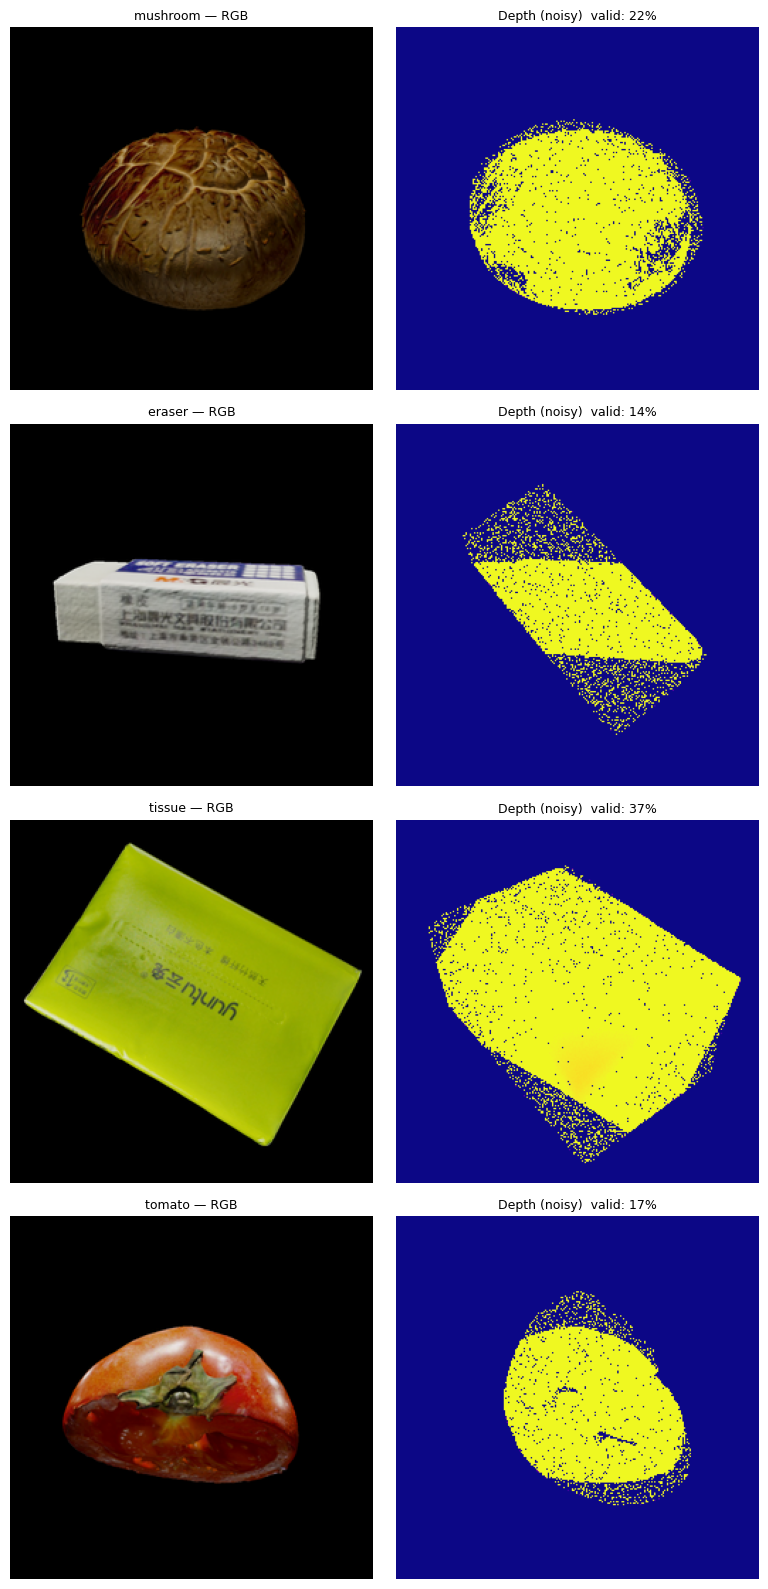

In [12]:
import random as pyrandom
import matplotlib.pyplot as plt

# Rebuild paths list from train split for spot check
spot_rgb_paths, spot_depth_paths, spot_labels = [], [], []
for cat_name in INDOOR_CATS:
    cat_dir = Path(BASE_OUT_DIR) / 'train' / cat_name
    if not cat_dir.exists():
        continue
    label_idx = cat_to_idx[cat_name]
    for rf in sorted(cat_dir.glob('*_rgb.pt')):
        df = Path(str(rf).replace('_rgb.pt', '_depth.pt'))
        if df.exists():
            spot_rgb_paths.append(rf)
            spot_depth_paths.append(df)
            spot_labels.append(label_idx)

picks = pyrandom.sample(range(len(spot_rgb_paths)), 4)
fig, axes = plt.subplots(4, 2, figsize=(8, 16))

for i, idx in enumerate(picks):
    rgb_np   = torch.load(spot_rgb_paths[idx],   weights_only=True).permute(1, 2, 0).numpy()
    depth_np = torch.load(spot_depth_paths[idx], weights_only=True).squeeze(0).numpy().astype(float)
    valid    = (depth_np > 0).mean()
    cat      = INDOOR_CATS[spot_labels[idx]]
    axes[i][0].imshow(rgb_np)
    axes[i][0].set_title(f'{cat} — RGB', fontsize=9)
    axes[i][0].axis('off')
    axes[i][1].imshow(depth_np, cmap='plasma', vmin=0, vmax=3000)
    axes[i][1].set_title(f'Depth (noisy)  valid: {valid:.0%}', fontsize=9)
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()


## 12. Package and Upload to Drive

In [13]:
local_tar = '/content/OmniObject3D_Pretrain_256.tar.gz'

print('Creating tar.gz...')
with tarfile.open(local_tar, 'w:gz') as tar:
    tar.add(BASE_OUT_DIR, arcname='sparse_omni_256')

size_gb = os.path.getsize(local_tar) / 1e9
print(f'Archive size: {size_gb:.2f} GB')

print('Uploading to Drive...')
shutil.copy(local_tar, DRIVE_OUTPUT_TAR)
print(f'Saved to: {DRIVE_OUTPUT_TAR}')

os.remove(local_tar)
shutil.rmtree(BASE_OUT_DIR)
shutil.rmtree(TMP_DIR, ignore_errors=True)
print('VM disk cleaned')
!df -h /content

Creating tar.gz...
Archive size: 9.70 GB
Uploading to Drive...
Saved to: /content/drive/MyDrive/datasets/OmniObject3D_Pretrain_256.tar.gz
VM disk cleaned
Filesystem      Size  Used Avail Use% Mounted on
overlay         226G   52G  175G  23% /
